# Review Score Prediction – Olist E-Commerce

**Objective:**  
Predict whether an order is likely to receive a **low review score (1–2 stars)**.

**Business Value:**  
Early warning system for customer dissatisfaction, so Olist can intervene before a negative review is submitted.

**Approach:**  
Binary Classification  
- `1` = Low score (review_score ≤ 2)  
- `0` = Normal/High score (review_score ≥ 3)

### Imports

In [158]:
# Data Manipulation & Viz
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    f1_score, make_scorer,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Successfully Imported")

Successfully Imported


### Data Loading

In [159]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

dataset = "olistbr/brazilian-ecommerce"

customers = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, dataset, "olist_customers_dataset.csv")
orders = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, dataset, "olist_orders_dataset.csv")
order_items = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, dataset, "olist_order_items_dataset.csv")
order_payments = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, dataset, "olist_order_payments_dataset.csv")
order_reviews = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, dataset, "olist_order_reviews_dataset.csv")
products = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, dataset, "olist_products_dataset.csv")
sellers = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, dataset, "olist_sellers_dataset.csv")
category_translation = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, dataset, "product_category_name_translation.csv")

print("Data loaded successfully")
print('_'*60)
print("customers:", customers.shape)
print("orders:", orders.shape)
print("order_items:", order_items.shape)
print("order_reviews:", order_reviews.shape)
print("order_payments:", order_payments.shape)
print("products:", products.shape)
print("sellers:", sellers.shape)
print("category_translation:", category_translation.shape)

Data loaded successfully
____________________________________________________________
customers: (99441, 5)
orders: (99441, 8)
order_items: (112650, 7)
order_reviews: (99224, 7)
order_payments: (103886, 5)
products: (32951, 9)
sellers: (3095, 4)
category_translation: (71, 2)


### 1. Data Preparation

We will create one modeling table by joining:
- orders
- order_reviews
- order_items
- customers
- sellers
- products + category translation
- order_payments

In [160]:
# Convert dates
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'], errors='coerce')
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'], errors='coerce')
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'], errors='coerce')


# Delivery Feature = Delivered Date - Estimated Date
orders['delivery_delay'] = (
    orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']
).dt.days

orders.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-6.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-18.0


In [161]:
# Latency Flag
orders['is_late'] = (orders['delivery_delay'] > 0).astype(int)

orders.shape

(99441, 10)

In [162]:
orders["order_month"] = orders["order_purchase_timestamp"].dt.month

In [163]:
# Category Translation
products = products.merge(
    category_translation,
    on='product_category_name',
    how='left'
)

products.head(3)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure


In [164]:
# Items Aggregation per Order
items_per_order = order_items.groupby('order_id').agg(
    total_items = ('order_item_id', 'count'),
    price = ('price', 'sum'),
    freight = ('freight_value', 'sum'),
).reset_index()

items_per_order.head()

,order_id,total_items,price,freight
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14


In [165]:
# First product & seller in the order
first_item = (
    order_items.sort_values("order_item_id")
    .groupby("order_id")
    .first()[["product_id", "seller_id"]]
    .reset_index()
)

first_item.head()

,order_id,product_id,seller_id
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87


In [166]:
# First payment info
pay = (
    order_payments.sort_values("payment_sequential")
    .groupby("order_id")
    .first()[["payment_type", "payment_installments"]]
    .reset_index()
)

pay.head()

,order_id,payment_type,payment_installments
0,00010242fe8c5a6d1ba2dd792cb16214,credit_card,2
1,00018f77f2f0320c557190d7a144bdd3,credit_card,3
2,000229ec398224ef6ca0657da4fc703e,credit_card,5
3,00024acbcdf0a6daa1e931b038114c75,credit_card,2
4,00042b26cf59d7ce69dfabb4e55b4fd9,credit_card,3


In [167]:
# Modeling DataFrame

df = (
    orders[[
        "order_id", "customer_id", "order_month",
        "delivery_delay", "is_late"
    ]]
    .merge(order_reviews[["order_id", "review_score"]], on="order_id", how="inner")
    .merge(items_per_order, on="order_id", how="inner")
    .merge(first_item, on="order_id", how="left")
    .merge(customers[["customer_id", "customer_state"]], on="customer_id", how="left")
    .merge(sellers[["seller_id", "seller_state"]], on="seller_id", how="left")
    .merge(products[["product_id", "product_category_name_english"]], on="product_id", how="left")
    .merge(pay, on="order_id", how="left")
)

df.head()

,order_id,customer_id,order_month,delivery_delay,is_late,review_score,total_items,price,freight,product_id,seller_id,customer_state,seller_state,product_category_name_english,payment_type,payment_installments
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,10,-8.0,0,4,1,29.99,8.72,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,SP,SP,housewares,credit_card,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,7,-6.0,0,4,1,118.70,22.76,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,BA,SP,perfumery,boleto,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,8,-18.0,0,5,1,159.90,19.22,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,GO,SP,auto,credit_card,3.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,11,-13.0,0,5,1,45.00,27.20,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,RN,MG,pet_shop,credit_card,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2,-10.0,0,5,1,19.90,8.72,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,SP,SP,stationery,credit_card,1.0


In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98465 entries, 0 to 98464
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       98465 non-null  object 
 1   customer_id                    98465 non-null  object 
 2   order_month                    98465 non-null  int32  
 3   delivery_delay                 96359 non-null  float64
 4   is_late                        98465 non-null  int64  
 5   review_score                   98465 non-null  int64  
 6   total_items                    98465 non-null  int64  
 7   price                          98465 non-null  float64
 8   freight                        98465 non-null  float64
 9   product_id                     98465 non-null  object 
 10  seller_id                      98465 non-null  object 
 11  customer_state                 98465 non-null  object 
 12  seller_state                   98465 non-null 

In [169]:
# Create the Target
df['low_score'] = (df['review_score'] <= 2).astype(int)

print("Modeling dataset shape:", df.shape)
print("Low score rate: {:.2f}%".format(df["low_score"].mean() * 100))
df.head()

Modeling dataset shape: (98465, 17)
Low score rate: 14.19%


,order_id,customer_id,order_month,delivery_delay,is_late,review_score,total_items,price,freight,product_id,seller_id,customer_state,seller_state,product_category_name_english,payment_type,payment_installments,low_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,10,-8.0,0,4,1,29.99,8.72,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,SP,SP,housewares,credit_card,1.0,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,7,-6.0,0,4,1,118.70,22.76,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,BA,SP,perfumery,boleto,1.0,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,8,-18.0,0,5,1,159.90,19.22,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,GO,SP,auto,credit_card,3.0,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,11,-13.0,0,5,1,45.00,27.20,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,RN,MG,pet_shop,credit_card,1.0,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2,-10.0,0,5,1,19.90,8.72,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,SP,SP,stationery,credit_card,1.0,0


### 2. Data Cleaning
- Missing Values
- Duplicates
- Wrong Formats

In [170]:
# Percentage of Missing Values
df.isnull().sum() / len(df)

order_id                         0.000000
customer_id                      0.000000
order_month                      0.000000
delivery_delay                   0.021388
is_late                          0.000000
review_score                     0.000000
total_items                      0.000000
price                            0.000000
freight                          0.000000
product_id                       0.000000
seller_id                        0.000000
customer_state                   0.000000
seller_state                     0.000000
product_category_name_english    0.014574
payment_type                     0.000010
payment_installments             0.000010
low_score                        0.000000
dtype: float64

In [171]:
print(f"BEFORE = {df.shape}")
df = df.dropna()
print(f"AFTER = {df.shape}")

BEFORE = (98465, 17)
AFTER = (94981, 17)


In [172]:
df.duplicated().sum()

np.int64(335)

In [173]:
print(f"BEFORE = {df.shape}")
df = df.drop_duplicates()
print(f"AFTER = {df.shape}")

BEFORE = (94981, 17)
AFTER = (94646, 17)


In [174]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94646 entries, 0 to 98464
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       94646 non-null  object 
 1   customer_id                    94646 non-null  object 
 2   order_month                    94646 non-null  int32  
 3   delivery_delay                 94646 non-null  float64
 4   is_late                        94646 non-null  int64  
 5   review_score                   94646 non-null  int64  
 6   total_items                    94646 non-null  int64  
 7   price                          94646 non-null  float64
 8   freight                        94646 non-null  float64
 9   product_id                     94646 non-null  object 
 10  seller_id                      94646 non-null  object 
 11  customer_state                 94646 non-null  object 
 12  seller_state                   94646 non-null  obje

In [175]:
df.head()

,order_id,customer_id,order_month,delivery_delay,is_late,review_score,total_items,price,freight,product_id,seller_id,customer_state,seller_state,product_category_name_english,payment_type,payment_installments,low_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,10,-8.0,0,4,1,29.99,8.72,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,SP,SP,housewares,credit_card,1.0,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,7,-6.0,0,4,1,118.70,22.76,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,BA,SP,perfumery,boleto,1.0,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,8,-18.0,0,5,1,159.90,19.22,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,GO,SP,auto,credit_card,3.0,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,11,-13.0,0,5,1,45.00,27.20,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,RN,MG,pet_shop,credit_card,1.0,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2,-10.0,0,5,1,19.90,8.72,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,SP,SP,stationery,credit_card,1.0,0


### 3. Feature Selection

**Selected Features:**
- `is_late`
- `delivery_delay`
- `price`
- `freight`
- `total_items`
- `payment_installments`
- `order_month`
- `customer_state`
- `seller_state`
- `product_category_name_english`
- `payment_type`

**Target:**
- `low_score`

In [176]:
features = [
    'is_late',
    'delivery_delay',
    'price',
    'freight',
    'total_items',
    'payment_installments',
    'order_month',
    'customer_state',
    'seller_state',
    'product_category_name_english',
    'payment_type'
]

categorical_cols = [
    'customer_state',
    'seller_state',
    'product_category_name_english',
    'payment_type'
]

In [177]:
data = df[features + ['low_score']]

data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94646 entries, 0 to 98464
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   is_late                        94646 non-null  int64  
 1   delivery_delay                 94646 non-null  float64
 2   price                          94646 non-null  float64
 3   freight                        94646 non-null  float64
 4   total_items                    94646 non-null  int64  
 5   payment_installments           94646 non-null  float64
 6   order_month                    94646 non-null  int32  
 7   customer_state                 94646 non-null  object 
 8   seller_state                   94646 non-null  object 
 9   product_category_name_english  94646 non-null  object 
 10  payment_type                   94646 non-null  object 
 11  low_score                      94646 non-null  int64  
dtypes: float64(4), int32(1), int64(3), object(4)
memory

#### Categorical Encoding

In [178]:
df['customer_state'].value_counts()

customer_state
SP    39779
RJ    12069
MG    11134
RS     5257
PR     4838
SC     3466
BA     3194
DF     2047
ES     1954
GO     1908
PE     1564
CE     1262
PA      917
MT      869
MA      704
MS      694
PB      504
RN      466
PI      464
AL      391
SE      332
TO      270
RO      237
AM      143
AC       78
AP       66
RR       39
Name: count, dtype: int64

In [179]:
df['seller_state'].value_counts()

seller_state
SP    67093
MG     7447
PR     7350
RJ     4089
SC     3518
RS     1898
DF      793
BA      547
GO      441
PE      401
MA      384
ES      298
MT      134
CE       85
RN       51
MS       46
PB       29
RO       13
PI       11
PA        8
SE        7
AM        3
Name: count, dtype: int64

In [180]:
df['product_category_name_english'].value_counts()

product_category_name_english
bed_bath_table               9125
health_beauty                8574
sports_leisure               7459
computers_accessories        6490
furniture_decor              6191
                             ... 
home_comfort_2                 21
cds_dvds_musicals              12
la_cuisine                     11
fashion_childrens_clothes       7
security_and_services           2
Name: count, Length: 71, dtype: int64

In [181]:
df['payment_type'].value_counts()

payment_type
credit_card    72888
boleto         18839
voucher         1470
debit_card      1449
Name: count, dtype: int64

In [182]:
# One Hot Encoding
data = pd.get_dummies(data, columns=['payment_type'], drop_first=True)
print(f"Shape: {data.shape}")

data.head()

Shape: (94646, 14)


,is_late,delivery_delay,price,freight,total_items,payment_installments,order_month,customer_state,seller_state,product_category_name_english,low_score,payment_type_credit_card,payment_type_debit_card,payment_type_voucher
0,0,-8.0,29.99,8.72,1,1.0,10,SP,SP,housewares,0,True,False,False
1,0,-6.0,118.70,22.76,1,1.0,7,BA,SP,perfumery,0,False,False,False
2,0,-18.0,159.90,19.22,1,3.0,8,GO,SP,auto,0,True,False,False
3,0,-13.0,45.00,27.20,1,1.0,11,RN,MG,pet_shop,0,True,False,False
4,0,-10.0,19.90,8.72,1,1.0,2,SP,SP,stationery,0,True,False,False


In [183]:
# Label Encoding - As columns are not Ordinal (Nominal)
for col in ['customer_state', 'seller_state', 'product_category_name_english']:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))

print(f"Shape: {data.shape}")

data.head()

Shape: (94646, 14)


,is_late,delivery_delay,price,freight,total_items,payment_installments,order_month,customer_state,seller_state,product_category_name_english,low_score,payment_type_credit_card,payment_type_debit_card,payment_type_voucher
0,0,-8.0,29.99,8.72,1,1.0,10,25,21,49,0,True,False,False
1,0,-6.0,118.70,22.76,1,1.0,7,4,21,59,0,False,False,False
2,0,-18.0,159.90,19.22,1,3.0,8,8,21,5,0,True,False,False
3,0,-13.0,45.00,27.20,1,1.0,11,19,7,60,0,True,False,False
4,0,-10.0,19.90,8.72,1,1.0,2,25,21,66,0,True,False,False


In [184]:
# Check Imbalance
df['low_score'].value_counts()

low_score
0    82556
1    12090
Name: count, dtype: int64

### 4. Data Splitting
1. Training Data    --> Models Training
2. Validation Data  --> Hyperparameter Tuning
3. Testing Data     --> Final Model Evaluation

In [185]:
X = data.drop('low_score', axis=1)
y = data['low_score']

print(f"Features: {X.shape[1]}")

Features: 13


In [186]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.24,
    random_state=42,
    stratify=y_temp
)

print(f"Training Data Shape: {X_train.shape}")
print(f"Validation Data Shape: {X_val.shape}")
print(f"Testing Data Shape: {X_test.shape}")

print(f"Training Size: {X_train.shape[0] / len(data):.2f}")
print(f"Validation Size: {X_val.shape[0] / len(data):.2f}")
print(f"Testing Size: {X_test.shape[0] / len(data):.2f}")

print("y_train low-score rate: {:.2f}%".format(y_train.mean() * 100))
print("y_train low-score rate: {:.2f}%".format(y_val.mean() * 100))
print("y_test  low-score rate: {:.2f}%".format(y_test.mean() * 100))

Training Data Shape: (57544, 13)
Validation Data Shape: (18172, 13)
Testing Data Shape: (18930, 13)
Training Size: 0.61
Validation Size: 0.19
Testing Size: 0.20
y_train low-score rate: 12.77%
y_train low-score rate: 12.77%
y_test  low-score rate: 12.77%


## 4. Model Training

We train two models:
1. Logistic Regression (baseline)
2. Random Forest (stronger non-linear model)
3. Gradient Boosting
4. XGBoost

`class_weight='balanced'` is used because low scores are minority class.

In [187]:
# scale_pos_weight = majority / minority
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight =", scale_pos_weight)

scale_pos_weight = 6.828050605359815


In [188]:
model_portfolio = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, 
        class_weight='balanced',
        random_state=42
    ),
    'Ranodm Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_features='sqrt',
        max_depth=10,
        min_samples_leaf=5,
        random_state=42,
    ),
    'XGBoost': XGBClassifier(
        objective='binary:logistic',
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )   
}

In [189]:
results = {}

for name, model in model_portfolio.items():
    # 1. Train
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_train_proba = model.predict_proba(X_train)[:, 1]

    # 2. Validation
    y_val_pred = model.predict(X_val)
    y_val_proba = model.predict_proba(X_val)[:, 1]

    # 3. Store Metrics
    results[name] = {
        'train_f1': f1_score(y_train, y_train_pred, pos_label=1),
        'val_f1': f1_score(y_val, y_val_pred, pos_label=1),
        'train_report':classification_report(y_train, y_train_pred, digits=3),
        'val_report': classification_report(y_val, y_val_pred, digits=3),
        'train_roc': roc_auc_score(y_train, y_train_pred),
        'val_roc': roc_auc_score(y_val, y_val_pred)
    }
    
    # 4. Print results
    print(f"\n===== {name} =====")
    print(f"Train F1: {results[name]['train_f1']:.3f} | Val F1: {results[name]['val_f1']:.3f}")
    print(f"Train ROC-AUC: {results[name]['train_roc']:.3f} | Val ROC-AUC: {results[name]['val_roc']:.3f}")
    print("\nValidation Report:")
    print(results[name]['val_report'])


===== Logistic Regression =====
Train F1: 0.446 | Val F1: 0.444
Train ROC-AUC: 0.696 | Val ROC-AUC: 0.694

Validation Report:
              precision    recall  f1-score   support

           0      0.924     0.890     0.907     15851
           1      0.399     0.499     0.444      2321

    accuracy                          0.840     18172
   macro avg      0.662     0.694     0.675     18172
weighted avg      0.857     0.840     0.847     18172


===== Ranodm Forest =====
Train F1: 0.482 | Val F1: 0.449
Train ROC-AUC: 0.713 | Val ROC-AUC: 0.693

Validation Report:
              precision    recall  f1-score   support

           0      0.923     0.901     0.912     15851
           1      0.418     0.486     0.449      2321

    accuracy                          0.848     18172
   macro avg      0.670     0.693     0.681     18172
weighted avg      0.858     0.848     0.853     18172


===== Gradient Boosting =====
Train F1: 0.664 | Val F1: 0.405
Train ROC-AUC: 0.751 | Val ROC-AUC:

### 5. Hyperparameter Tuning
- Applied to the best model -> [XGBoost]

In [190]:
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

param_dist = {
    'n_estimators': [200, 300, 400, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3],
    'reg_lambda': [1, 1.5, 2, 3],
    'scale_pos_weight': [scale_pos_weight, scale_pos_weight * 0.8, scale_pos_weight * 1.2]
}

f1_scorer = make_scorer(f1_score, pos_label=1)

In [191]:
search = RandomizedSearchCV(
    estimator = xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring=f1_scorer,
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                                          0.1],
                                        'max_depth': [3, 4, 5, 6],
                                        'min_child_weight': [1, 3, 5, 7],
                                        'n_estimators': [200, 300, 400, 500],
                                        'reg_lambda': [1, 1.5, 2, 3],
                                        'scale_pos_weight': [np.float64(6.828050605359815),
                                                             np.float64(5.4624404842878524),
                                                             np.float64(8.193660726431778)],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42,
                   scoring=make_scorer(f1_score, response_method='predict', pos_label=1),
                   verbose=1)

In [192]:
print("Best Params:")
print(search.best_params_)
print("Best CV F1:", round(search.best_score_, 3))

best_model = search.best_estimator_

Best Params:
{'subsample': 0.7, 'scale_pos_weight': np.float64(5.4624404842878524), 'reg_lambda': 2, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 0.9}
Best CV F1: 0.459


### 6. Best Model Evaluation

In [193]:
y_val_pred = best_model.predict(X_val)
y_val_proba = best_model.predict_proba(X_val)[:, 1]

print("===== Best XGBoost on Validation =====")
print(classification_report(y_val, y_val_pred, digits=3))
print("Val ROC-AUC:", round(roc_auc_score(y_val, y_val_proba), 3))
print(confusion_matrix(y_val, y_val_pred))

===== Best XGBoost on Validation =====
              precision    recall  f1-score   support

           0      0.923     0.902     0.913     15851
           1      0.422     0.487     0.452      2321

    accuracy                          0.849     18172
   macro avg      0.673     0.695     0.682     18172
weighted avg      0.859     0.849     0.854     18172

Val ROC-AUC: 0.74
[[14303  1548]
 [ 1191  1130]]


In [194]:
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

print("===== Final Test Evaluation =====")
print(classification_report(y_test, y_test_pred, digits=3))
print("Test ROC-AUC:", round(roc_auc_score(y_test, y_test_proba), 3))
print(confusion_matrix(y_test, y_test_pred))

===== Final Test Evaluation =====
              precision    recall  f1-score   support

           0      0.924     0.903     0.913     16512
           1      0.425     0.491     0.456      2418

    accuracy                          0.850     18930
   macro avg      0.674     0.697     0.684     18930
weighted avg      0.860     0.850     0.855     18930

Test ROC-AUC: 0.746
[[14903  1609]
 [ 1230  1188]]


### 7. Reporting

Feature Importance
is_late                          0.562592
total_items                      0.199216
delivery_delay                   0.100095
freight                          0.016749
product_category_name_english    0.015262
seller_state                     0.015108
payment_type_voucher             0.014880
price                            0.014477
order_month                      0.013729
payment_type_debit_card          0.013223
customer_state                   0.012911
payment_installments             0.012377
payment_type_credit_card         0.009381
dtype: float32


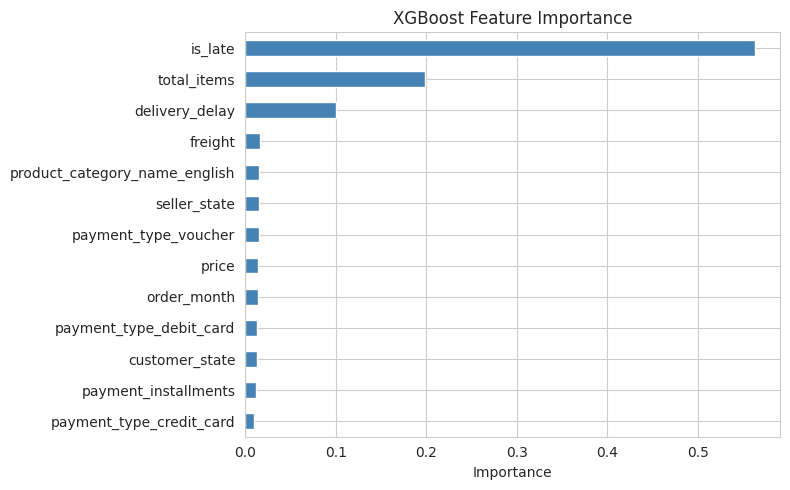

In [195]:
feat_imp = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Feature Importance")
print(feat_imp)

plt.figure(figsize=(8, 5))
feat_imp.sort_values().plot(kind="barh", color="steelblue")
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [197]:
from sklearn.metrics import precision_recall_curve

# Probabilities
y_val_proba = best_model.predict_proba(X_val)[:, 1]
y_test_proba = best_model.predict_proba(X_test)[:, 1]

# Default predictions (threshold = 0.5)
y_test_pred_default = best_model.predict(X_test)

# Best threshold from Validation (maximize F1 for class 1)
precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba)
f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores[:-1])  # last point has no threshold
best_threshold = thresholds[best_idx]

print("Best threshold:", round(best_threshold, 3))

# Tuned predictions
y_val_pred_adj = (y_val_proba >= best_threshold).astype(int)
y_test_pred_adj = (y_test_proba >= best_threshold).astype(int)

Best threshold: 0.567


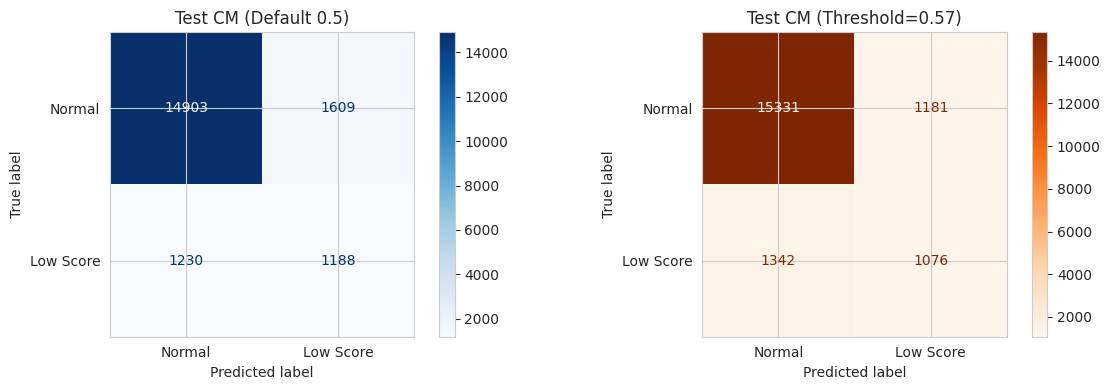

In [198]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred_default,
    display_labels=["Normal", "Low Score"],
    ax=axes[0],
    cmap="Blues"
)
axes[0].set_title("Test CM (Default 0.5)")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred_adj,
    display_labels=["Normal", "Low Score"],
    ax=axes[1],
    cmap="Oranges"
)
axes[1].set_title(f"Test CM (Threshold={best_threshold:.2f})")

plt.tight_layout()
plt.show()

In [199]:
val_report = classification_report(y_val, y_val_pred_adj, output_dict=True)
test_report = classification_report(y_test, y_test_pred_adj, output_dict=True)

summary = pd.DataFrame({
    "Metric": ["ROC-AUC", "Precision (Low)", "Recall (Low)", "F1 (Low)"],
    "Validation": [
        round(roc_auc_score(y_val, y_val_proba), 3),
        round(val_report["1"]["precision"], 3),
        round(val_report["1"]["recall"], 3),
        round(val_report["1"]["f1-score"], 3),
    ],
    "Test": [
        round(roc_auc_score(y_test, y_test_proba), 3),
        round(test_report["1"]["precision"], 3),
        round(test_report["1"]["recall"], 3),
        round(test_report["1"]["f1-score"], 3),
    ]
})

print(summary)

            Metric  Validation   Test
0          ROC-AUC       0.740  0.746
1  Precision (Low)       0.483  0.477
2     Recall (Low)       0.446  0.445
3         F1 (Low)       0.464  0.460


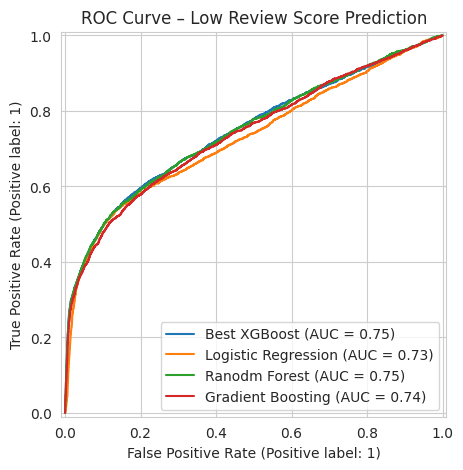

In [200]:
fig, ax = plt.subplots(figsize=(7, 5))

# Best tuned model
RocCurveDisplay.from_estimator(
    best_model, X_test, y_test, ax=ax, name="Best XGBoost"
)

# Optional: add other models if they exist in model_portfolio
if 'model_portfolio' in dir():
    for name, model in model_portfolio.items():
        if name != "XGBoost":  # already plotted as best if same
            try:
                RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
            except Exception:
                pass

plt.title("ROC Curve – Low Review Score Prediction")
plt.show()

## Final Model Performance

After fixing the delivery delay feature, the best XGBoost model achieved:

- **Test ROC-AUC:** 0.75
- **Low-score F1:** 0.46
- **Low-score Recall:** 0.49
- **Low-score Precision:** 0.43

Validation and Test metrics are nearly identical, indicating a stable model with no significant overfitting.

### Business Interpretation
The model can flag nearly half of the orders that will receive low review scores.
This enables Olist to trigger proactive customer support and reduce negative reviews,
at the acceptable cost of contacting some orders that would not have been low-rated.